## Initial Setup

### Feature complementarity across generators

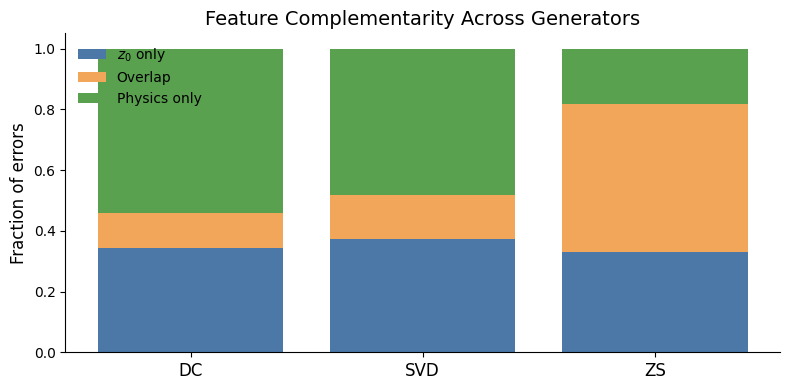

In [1]:
import matplotlib.pyplot as plt
import numpy as np

generators = ["DC", "SVD", "ZS"]

z0_only = np.array([411, 452, 604])
overlap = np.array([138, 176, 897])
physics_only = np.array([649, 587, 336])

total = z0_only + overlap + physics_only
z0_pct = z0_only / total
overlap_pct = overlap / total
phys_pct = physics_only / total

x = np.arange(len(generators))

BLUE = "#4C78A8"
ORANGE = "#F2A65A"
GREEN = "#59A14F"

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x, z0_pct, color=BLUE, label=r"$z_0$ only")
ax.bar(x, overlap_pct, bottom=z0_pct, color=ORANGE, label="Overlap")
ax.bar(x, phys_pct, bottom=z0_pct + overlap_pct, color=GREEN, label="Physics only")


ax.set_xticks(x)
ax.set_xticklabels(generators, fontsize=12)
ax.set_ylabel("Fraction of errors", fontsize=12)
ax.set_title("Feature Complementarity Across Generators", fontsize=14)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

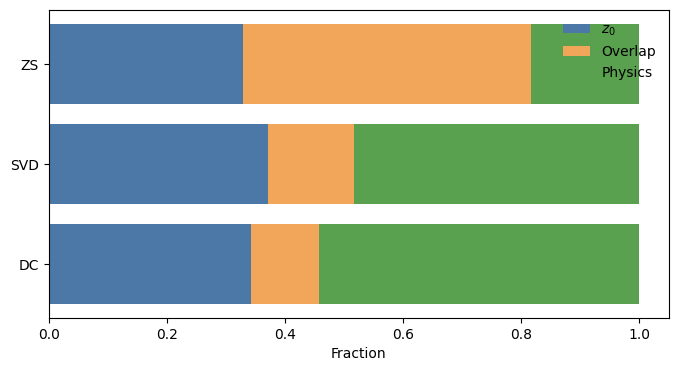

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(generators, z0_pct, color=BLUE, label=r"$z_0$")
ax.barh(generators, overlap_pct, left=z0_pct, color=ORANGE, label="Overlap")
ax.barh(generators, phys_pct, left=z0_pct + overlap_pct, color=GREEN, label="Physics")

ax.set_xlabel("Fraction")
ax.legend(frameon=False)

plt.show()

### Feature complementarity bar chart

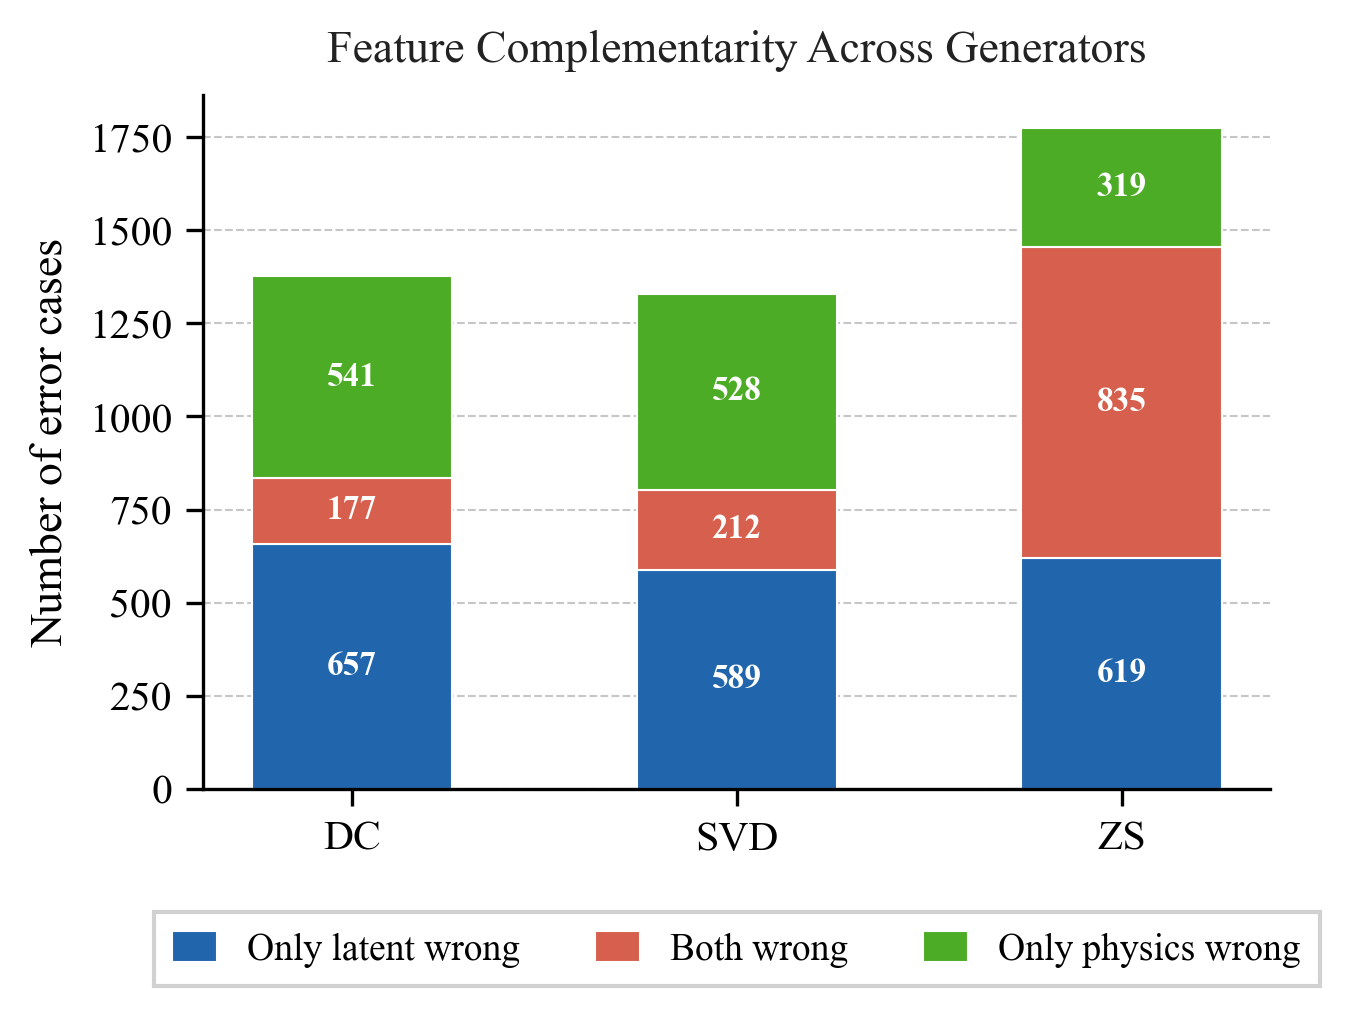

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 300,
    "text.usetex": False,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.axisbelow": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "grid.color": "#444444",
})


generators= ["DC", "SVD", "ZS"]
z0_only = np.array([657, 589, 619])
overlap = np.array([177, 212, 835])
physics_only = np.array([541, 528, 319])

x = np.arange(len(generators))
width = 0.52


C1 = "#2166ac" 
C2 = "#d6604d" 
C3 = "#4dac26" 


fig, ax = plt.subplots(figsize=(4.5, 3.4))

ax.bar(x, z0_only, width, color=C1, edgecolor="white", linewidth=0.5, label="Only latent wrong")
ax.bar(x, overlap, width, bottom=z0_only, color=C2, edgecolor="white", linewidth=0.5, label="Both wrong")
ax.bar(x, physics_only, width, bottom=z0_only + overlap, color=C3, edgecolor="white", linewidth=0.5, label="Only physics wrong")

ax.yaxis.grid(True, linestyle="--", zorder=0)

for i in range(len(generators)):
    v1, v2, v3 = z0_only[i], overlap[i], physics_only[i]
    if v1 > 80:
        ax.text(x[i], v1 / 2, str(v1), ha="center", va="center",
                fontsize=8, color="white", fontweight="bold")
    if v2 > 80:
        ax.text(x[i], v1 + v2 / 2, str(v2), ha="center", va="center",
                fontsize=8, color="white", fontweight="bold")
    if v3 > 80:
        ax.text(x[i], v1 + v2 + v3 / 2, str(v3), ha="center", va="center",
                fontsize=8, color="white", fontweight="bold")



ax.set_xticks(x)
ax.set_xticklabels(generators)
ax.set_ylabel("Number of error cases")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=True, framealpha=0.9, edgecolor="#cccccc",
    fancybox=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    handlelength=1.2,
    handleheight=0.9,
    borderpad=0.5,
)

ax.set_title("Feature Complementarity Across Generators",
             pad=8, loc="center", fontweight="normal", color="#222222")



plt.tight_layout(pad=0.6)

### Venn diagram -- error overlap latent vs physics (LOGO, 3 gen)

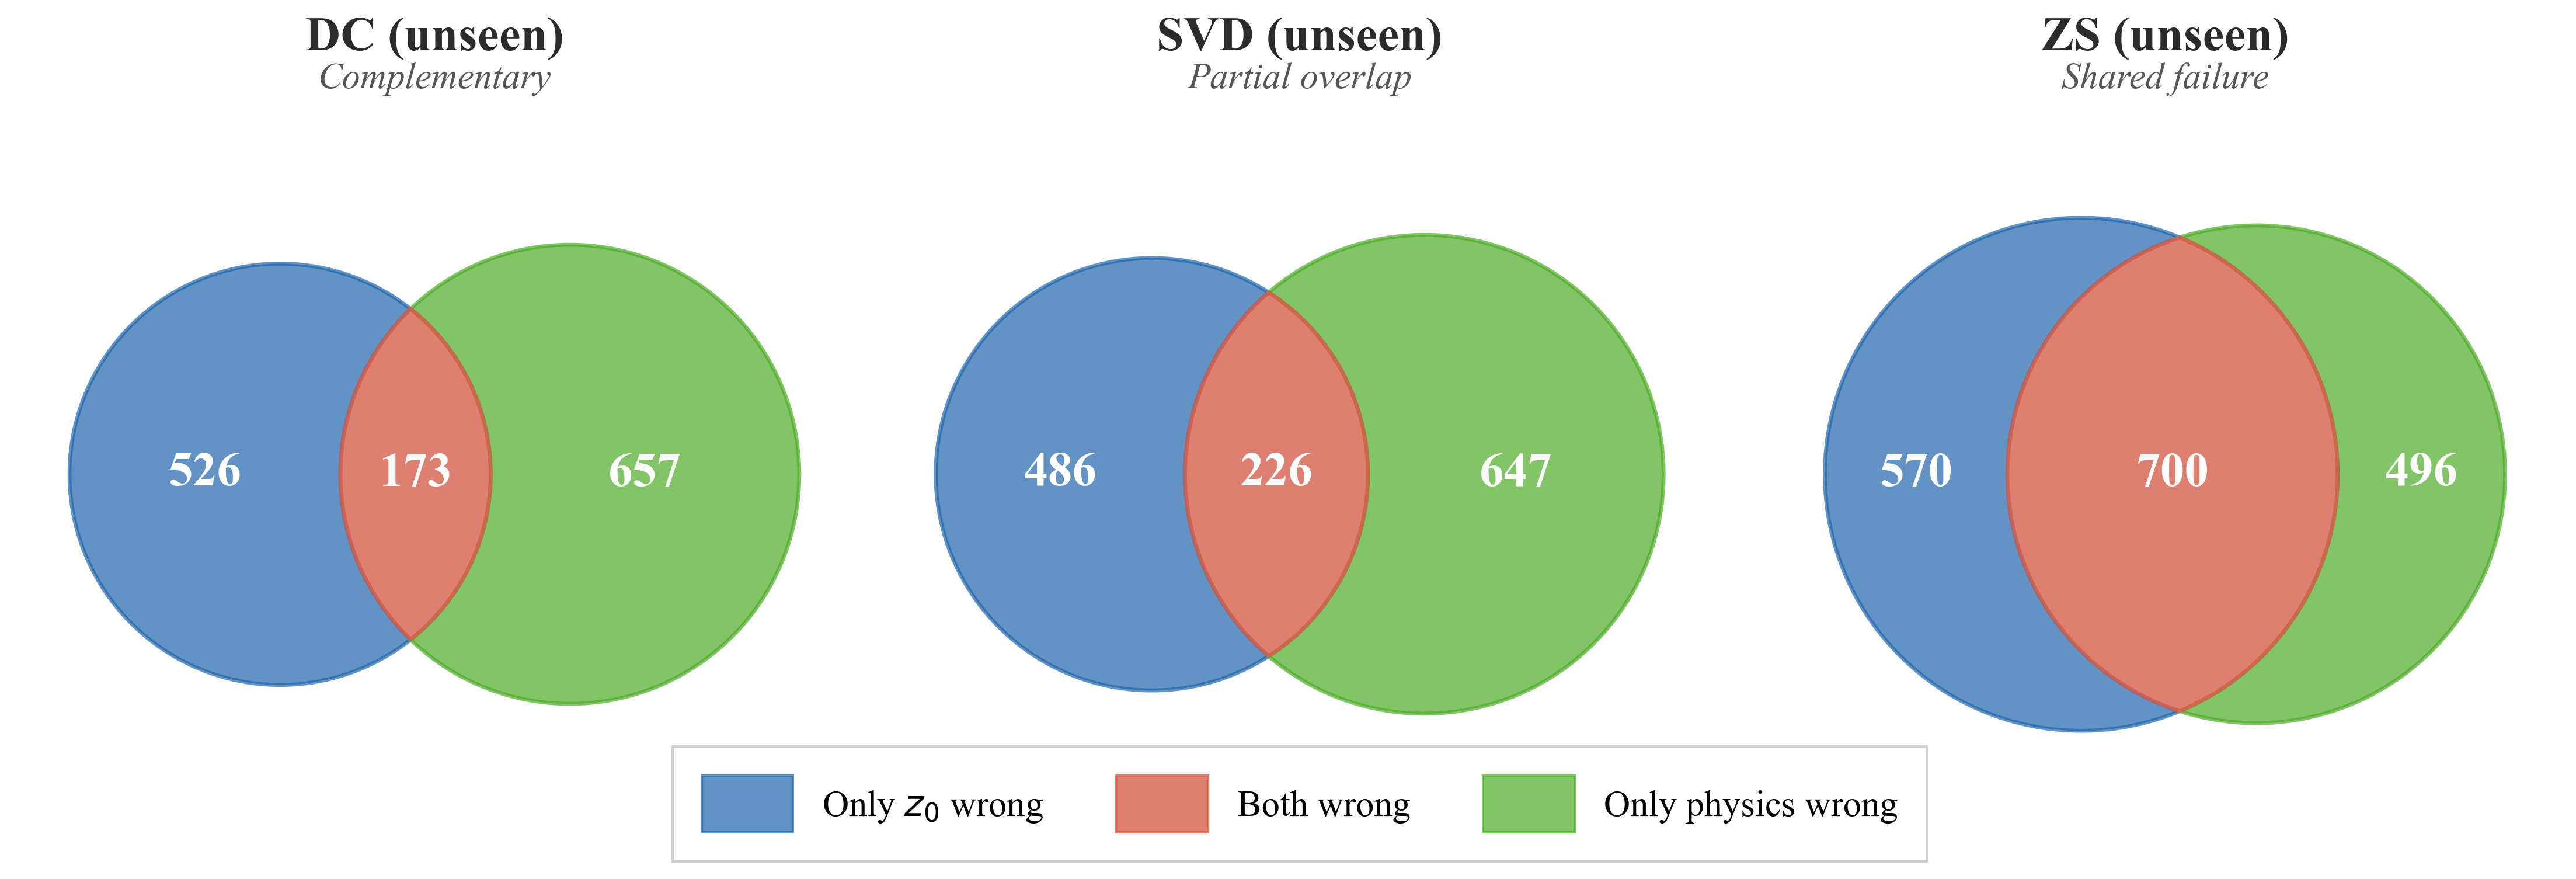

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib_venn import venn2
from matplotlib.patches import Patch

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size": 12,
    "figure.dpi": 300,
    "text.usetex": False,
})


cases = [
    {"title": "DC (unseen)", "subtitle": "Complementary", "values": (526, 173, 657)},
    {"title": "SVD (unseen)", "subtitle": "Partial overlap", "values": (486, 226, 647)},
    {"title": "ZS (unseen)", "subtitle": "Shared failure", "values": (570, 700, 496)},
]

C1 = "#2166ac"
C2 = "#d6604d"
C3 = "#4dac26"
TEXT = "#2b2b2b"
SUB  = "#555555"

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), facecolor="white")

for ax, case in zip(axes, cases):
    left_only, overlap, right_only = case["values"]
    v = venn2(subsets=(left_only, right_only, overlap), set_labels=("", ""), ax=ax)

    if v.get_patch_by_id("10"):
        v.get_patch_by_id("10").set(color=C1, alpha=0.7, edgecolor=C1, linewidth=1.6)
    if v.get_patch_by_id("01"):
        v.get_patch_by_id("01").set(color=C3, alpha=0.7, edgecolor=C3, linewidth=1.6)
    if v.get_patch_by_id("11"):
        v.get_patch_by_id("11").set(color=C2, alpha=0.8, edgecolor=C2, linewidth=1.6)

    for rid in ["10", "11", "01"]:
        lbl = v.get_label_by_id(rid)
        if lbl:
            lbl.set_fontsize(20)
            lbl.set_fontweight("semibold")
            lbl.set_color("white")

    for lbl in v.set_labels:
        if lbl:
            lbl.set_visible(False)

    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

plt.tight_layout(rect=[0.0, 0.10, 1.0, 0.85])


for ax, case in zip(axes, cases):
    bbox = ax.get_position()
    cx = (bbox.x0 + bbox.x1) / 2
    fig.text(cx, 0.93, case["title"], ha="center", va="bottom", fontsize=20, fontweight="bold", color=TEXT)
    fig.text(cx, 0.89, case["subtitle"], ha="center", va="bottom", fontsize=15, fontstyle="italic", color=SUB)


legend_handles = [
    Patch(facecolor=C1, alpha=0.7, edgecolor=C1, label=r"Only $z_0$ wrong"),
    Patch(facecolor=C2, alpha=0.8, edgecolor=C2, label="Both wrong"),
    Patch(facecolor=C3, alpha=0.7, edgecolor=C3, label="Only physics wrong"),
]


fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=15, frameon=True, framealpha=0.9, edgecolor="#cccccc",
           fancybox=False, handlelength=2.5, handleheight=2.0,
           borderpad=0.8, bbox_to_anchor=(0.5, 0.03))


### Confusion matrices per holdout generator

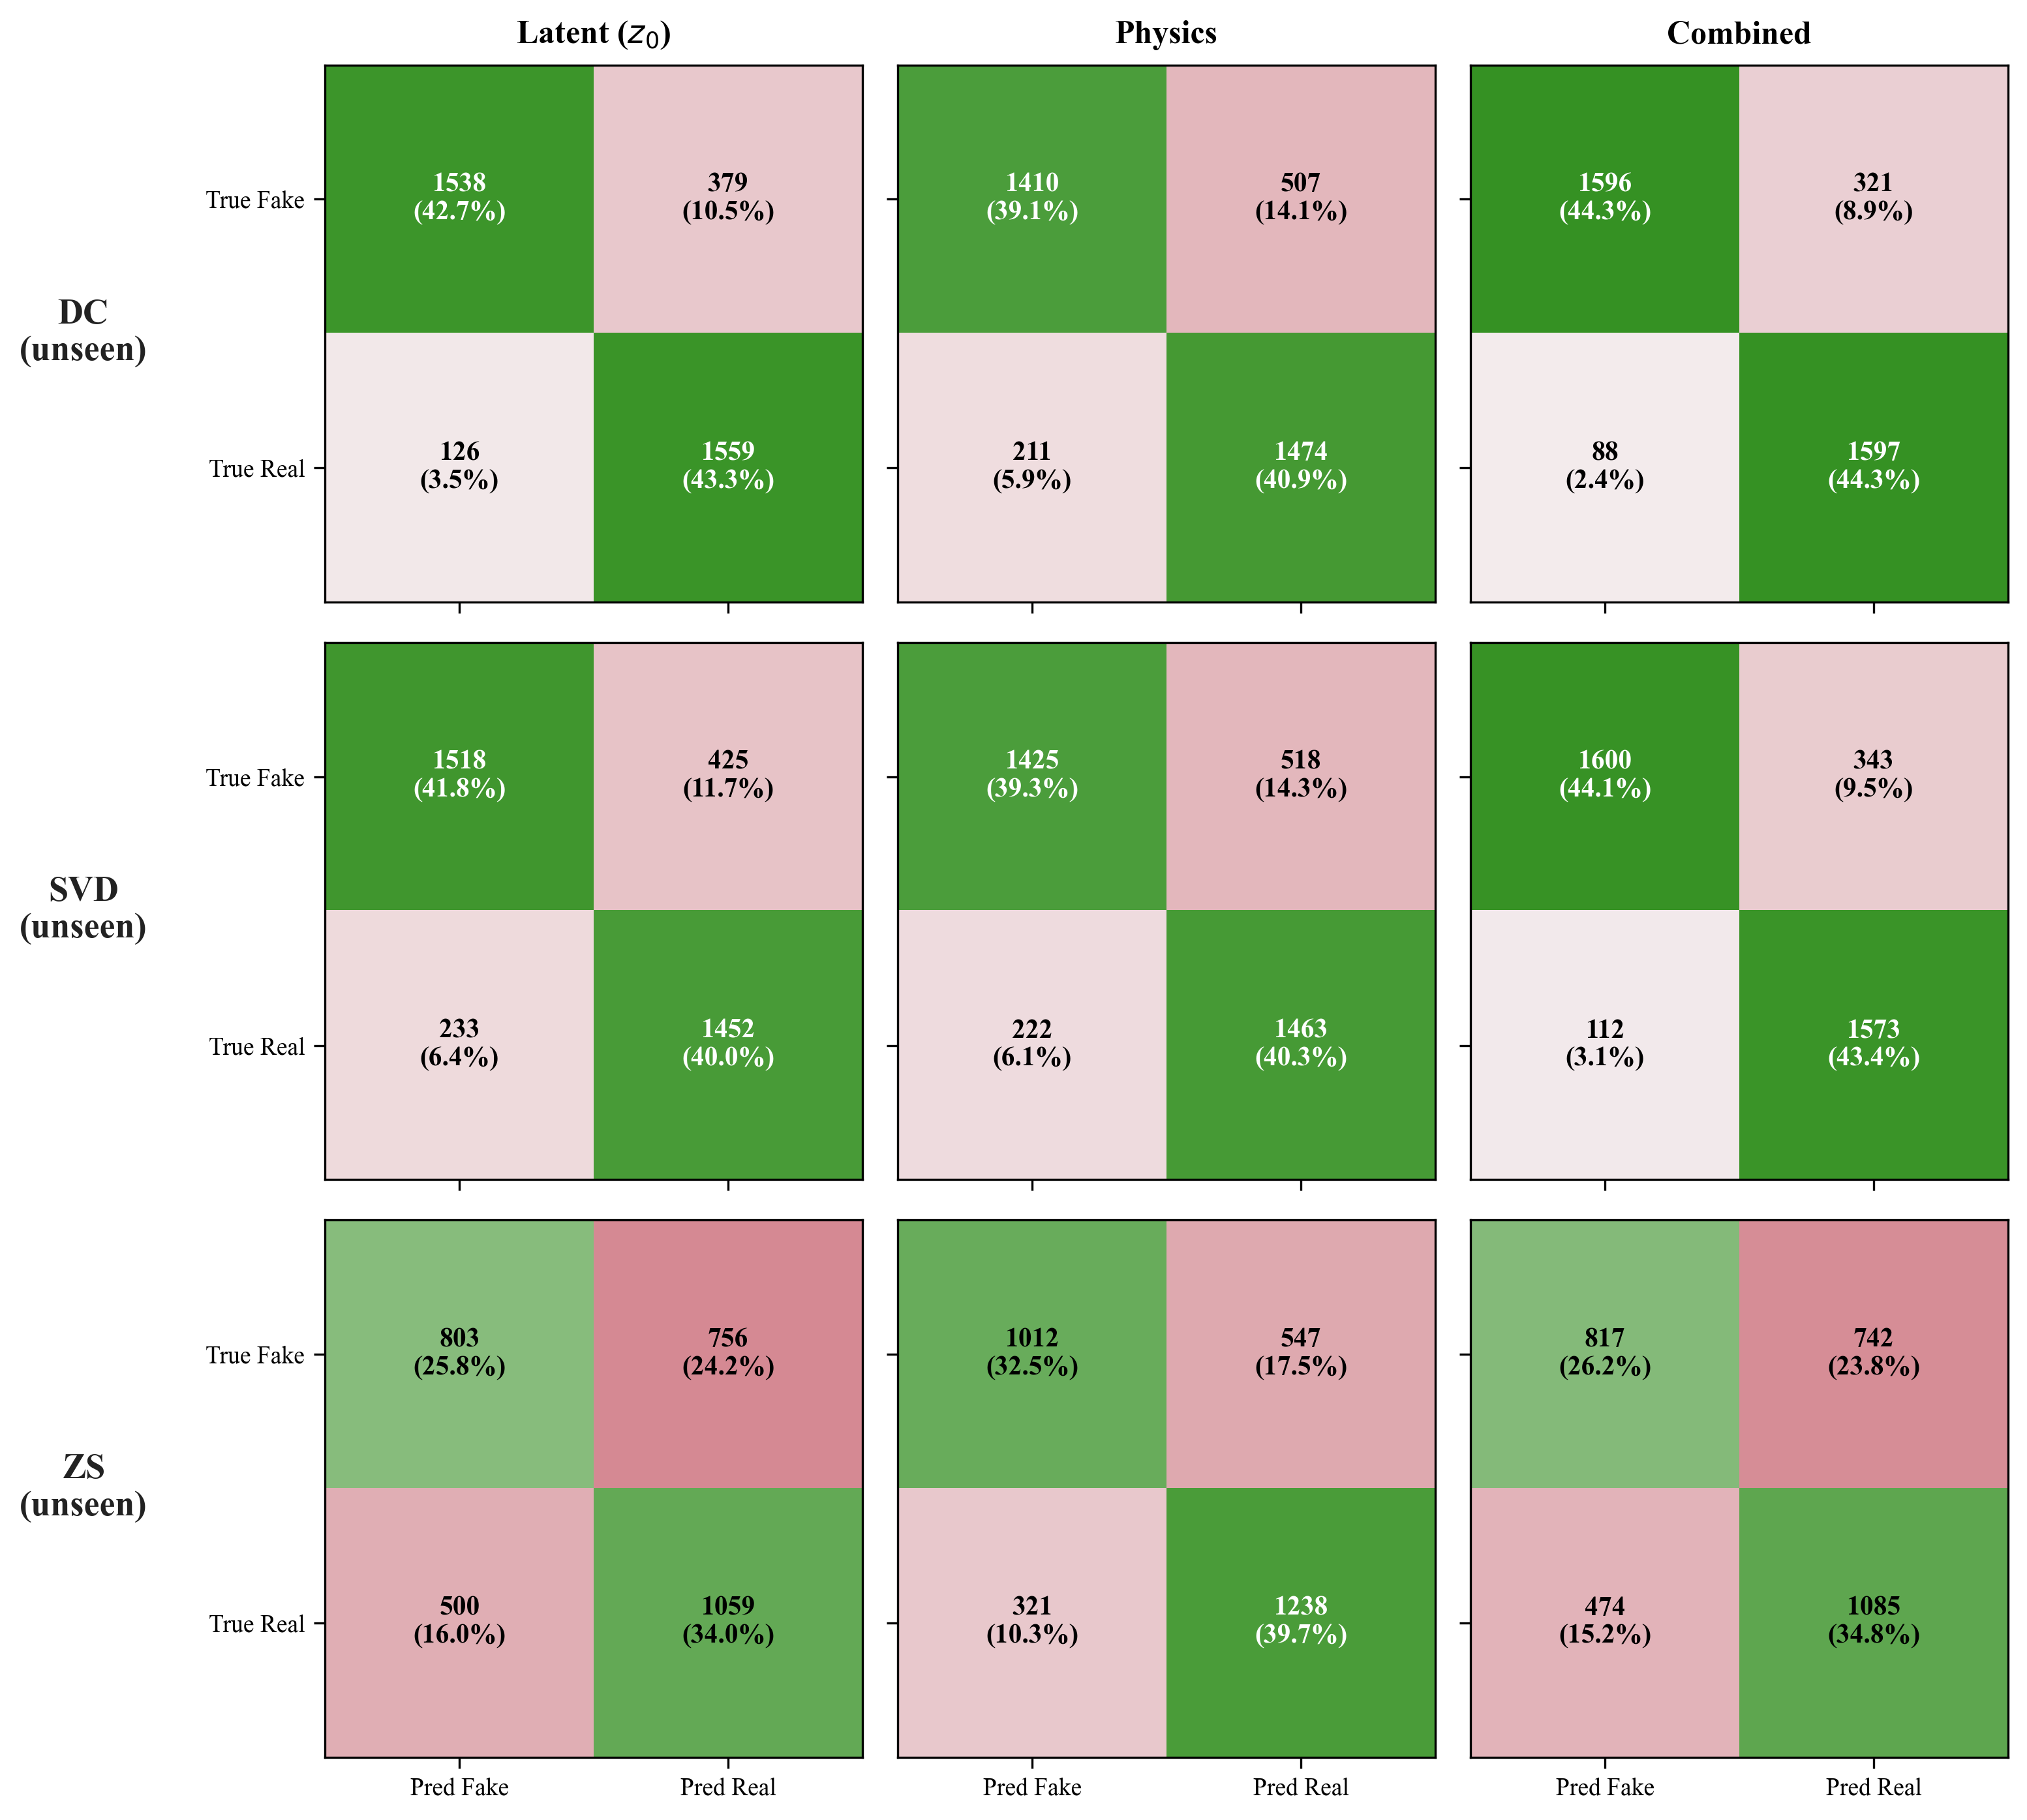

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


cm_data = {
    ("DC", "Latent ($z_0$)"): np.array([[1538, 379], [126, 1559]]),
    ("DC", "Physics"): np.array([[1410, 507], [211, 1474]]),
    ("DC", "Combined"): np.array([[1596, 321], [88, 1597]]),
    ("SVD", "Latent ($z_0$)"): np.array([[1518, 425], [233, 1452]]),
    ("SVD", "Physics"): np.array([[1425, 518], [222, 1463]]),
    ("SVD", "Combined"): np.array([[1600, 343], [112, 1573]]),
    ("ZS", "Latent ($z_0$)"): np.array([[803, 756], [500, 1059]]),
    ("ZS", "Physics"): np.array([[1012, 547], [321, 1238]]),
    ("ZS", "Combined"): np.array([[817, 742], [474, 1085]]),
}


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "figure.dpi": 300,
    "text.usetex": False,
})

gens = ["DC", "SVD", "ZS"]
branch_names = ["Latent ($z_0$)", "Physics", "Combined"]
labels = ["Fake", "Real"]

cmap = LinearSegmentedColormap.from_list("gwr", ["#b2182b", "#f7f7f7", "#1E8509"])

fig, axes = plt.subplots(3, 3, figsize=(11, 10))

for row, gen in enumerate(gens):
    for col, bname in enumerate(branch_names):
        ax = axes[row, col]
        cm = cm_data[(gen, bname)]
        total = cm.sum()
        cm_pct = cm / total * 100

        cm_color = np.zeros_like(cm, dtype=float)
        for i in range(2):
            for j in range(2):
                cm_color[i, j] = cm_pct[i, j] if i == j else -cm_pct[i, j]

        ax.imshow(cm_color, cmap=cmap, vmin=-50, vmax=50, aspect="equal")

        for i in range(2):
            for j in range(2):
                count = cm[i, j]
                pct = cm_pct[i, j]
                color = "white" if pct > 35 else "black"
                ax.text(j, i, f"{count}\n({pct:.1f}%)",
                        ha="center", va="center", fontsize=10,
                        fontweight="bold", color=color)

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])

        if row == 2:
            ax.set_xticklabels(["Pred Fake", "Pred Real"], fontsize=9)
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_yticklabels(["True Fake", "True Real"], fontsize=9)
        else:
            ax.set_yticklabels([])

        if row == 0:
            ax.set_title(bname, fontsize=12, fontweight="bold", pad=8)

        errs = total - np.trace(cm)
        err_pct = 100 * errs / total

        # ax.text(0.5, -0.12, f"errors: {errs}/{total} ({err_pct:.1f}%)",
        #         transform=ax.transAxes, ha="center", fontsize=9, color="#555555")

    axes[row, 0].text(-0.45, 0.5, f"{gen}\n(unseen)", transform=axes[row, 0].transAxes, ha="center", va="center", fontsize=13, fontweight="bold", color="#222222", rotation=0)

# fig.suptitle("Confusion Matrices: LOGO Holdout (XGBoost)", fontsize=14, fontweight="bold", y=0.98, color="#222222")

plt.tight_layout(rect=[0.06, 0.02, 1.0, 0.96])

## Extended Setup -- Ablation Study

### Standalone branch performance

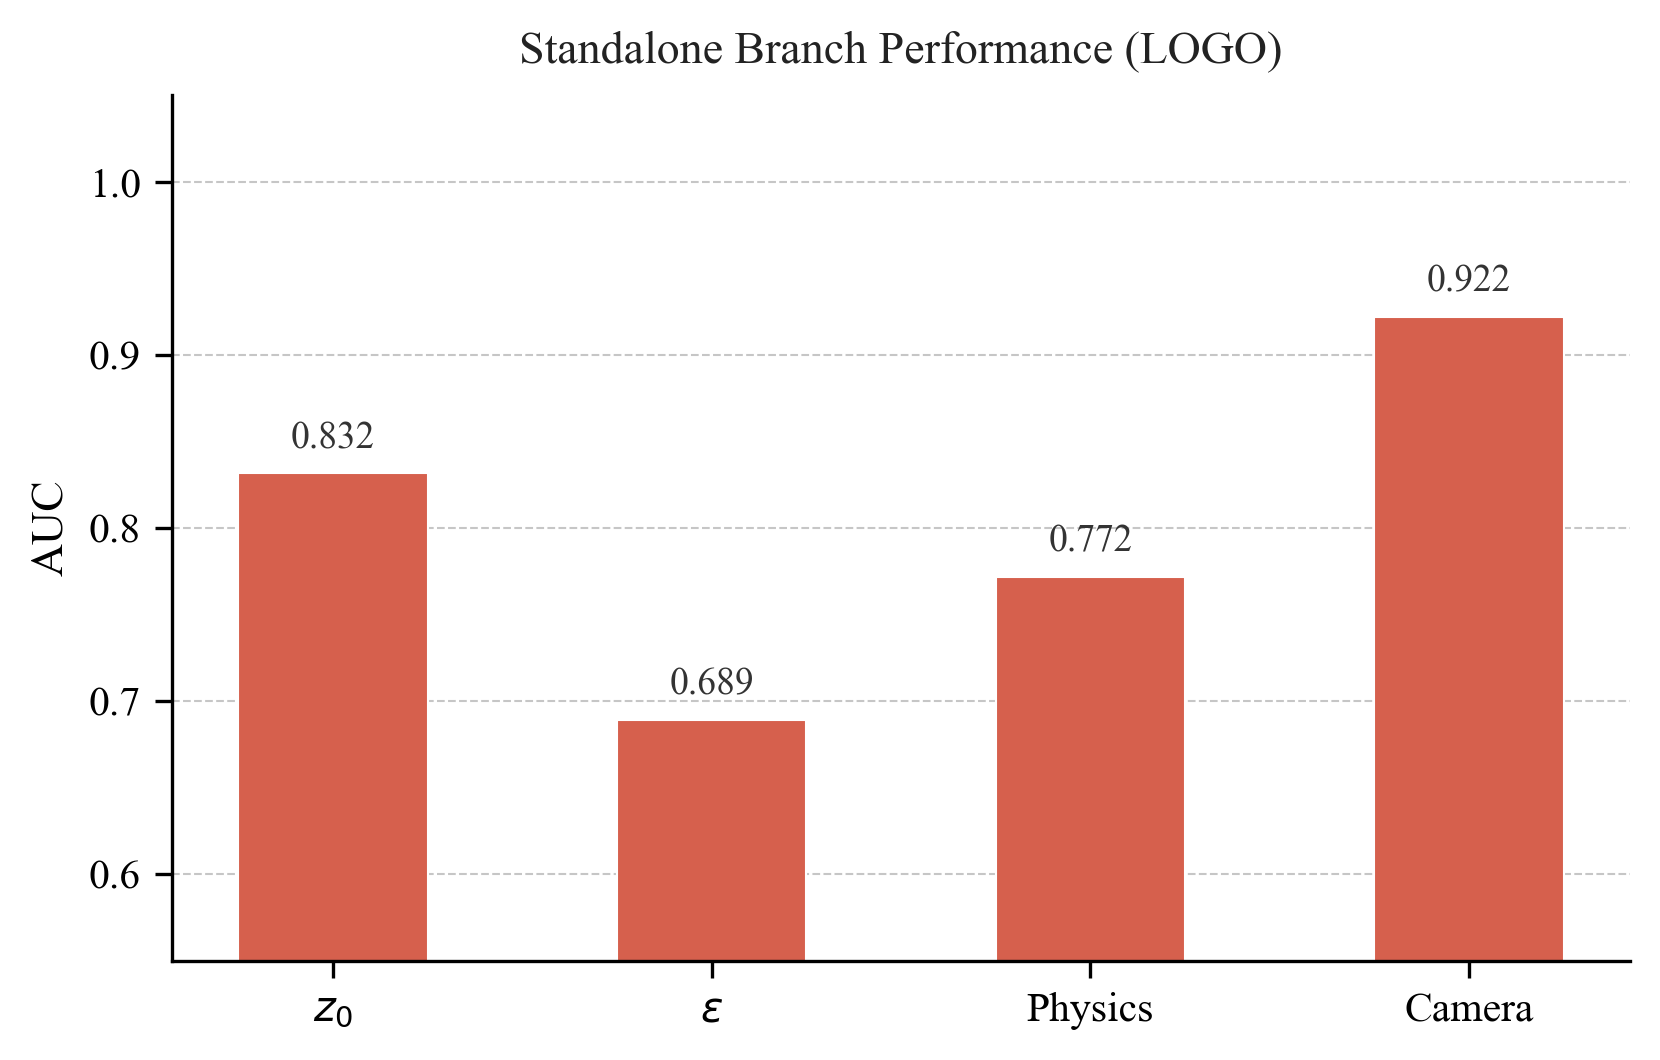

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "figure.dpi": 300,
    "text.usetex": False,
    "axes.axisbelow": True,
})

df = pd.read_csv("../results/ablation/results_ablation.csv")

standalone = df[~df["config"].str.contains(r"\+")].copy()
standalone = standalone[standalone["config"] != "all"]
standalone["label"] = standalone["config"].replace({
    "latent": r"$z_0$", "noise": r"$\epsilon$",
    "physics": "Physics", "camera": "Camera"
})
order = [r"$z_0$", r"$\epsilon$", "Physics", "Camera"]
standalone = standalone.set_index("label").loc[order].reset_index()

fig, ax = plt.subplots(figsize=(5.5, 3.5))

x = np.arange(len(standalone))
width = 0.5
C_HOLD = "#d6604d"

bars = ax.bar(x, standalone["mean"], width, label="LOGO AUC (mean)", color=C_HOLD, edgecolor="white", linewidth=0.5)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.3f}", ha="center", va="bottom", fontsize=9, color="#333333")

ax.set_xticks(x)
ax.set_xticklabels(standalone["label"])
ax.set_ylabel("AUC")
ax.set_ylim(0.55, 1.05)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Standalone Branch Performance (LOGO)", pad=8, fontweight="normal", color="#222222")

plt.tight_layout(pad=0.6)

### Marginal contribution (removal from full model)

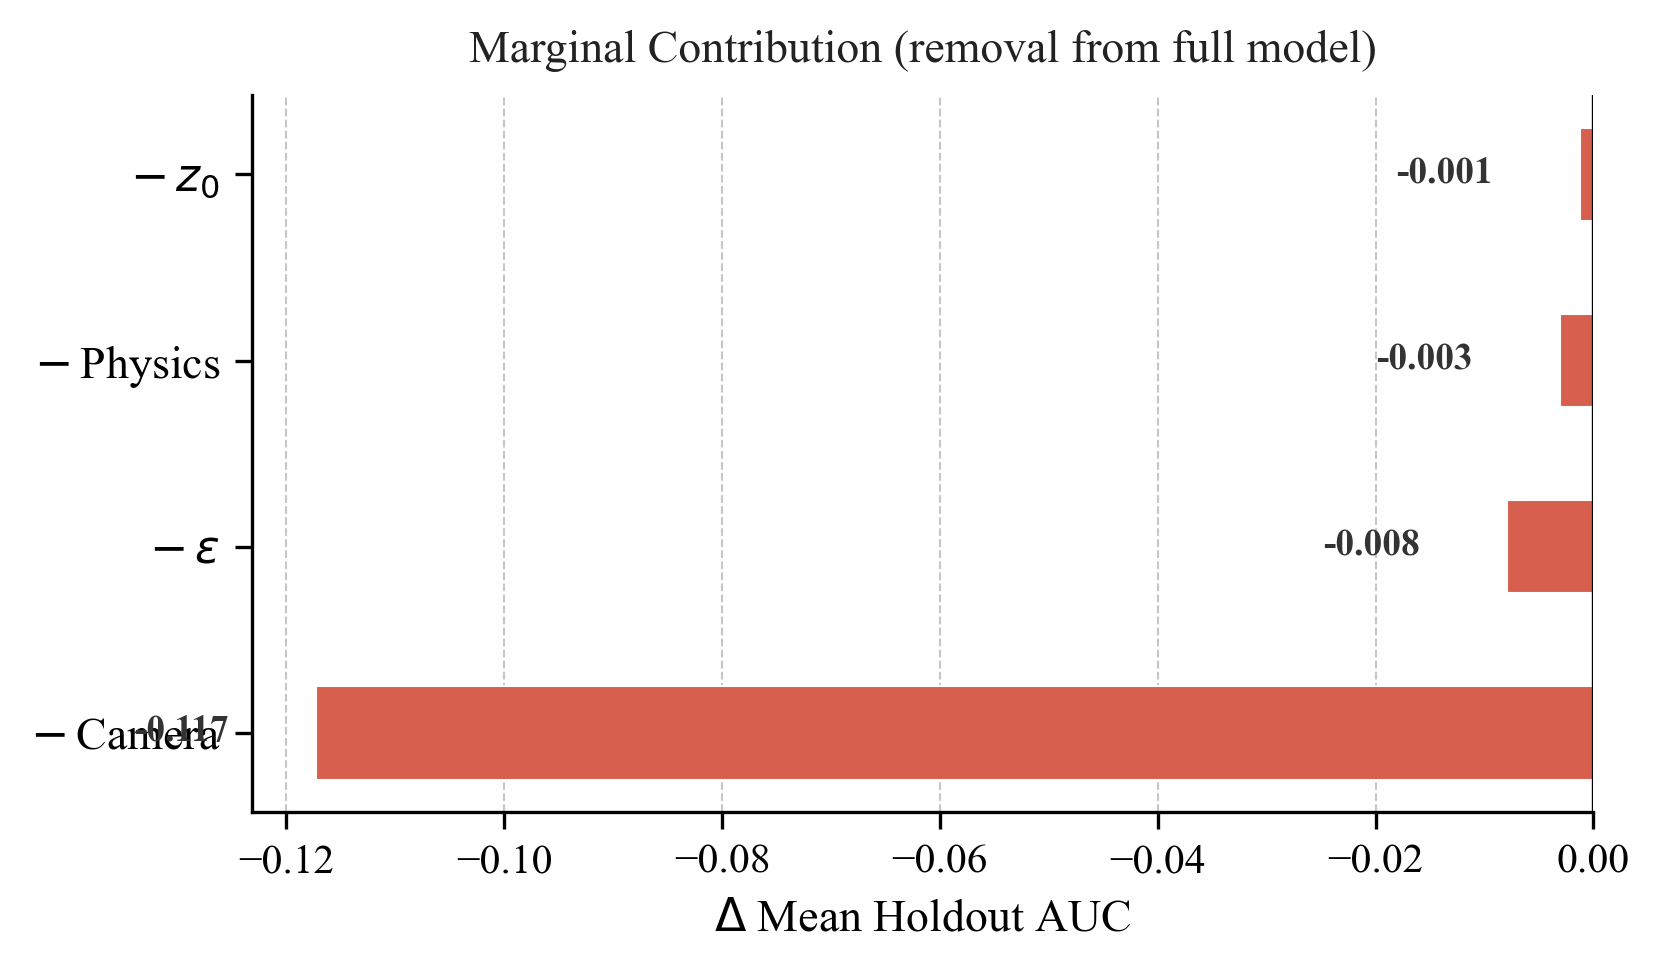

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size": 10,
    "figure.dpi": 300,
    "text.usetex": False,
    "axes.axisbelow": True,
})

df = pd.read_csv("../results/ablation/results_ablation.csv")
full = df[df["config"] == "all"].iloc[0]
full_mean = full["mean"]

branch_map = {"latent": r"$-\,z_0$", "noise": r"$-\,\epsilon$",
              "physics": "$-\\,$Physics", "camera": "$-\\,$Camera"}
branch_order = ["camera", "noise", "physics", "latent"]

deltas = []
for removed in branch_order:
    remaining = [b for b in ["latent", "noise", "physics", "camera"] if b != removed]
    remaining_key = "+".join(sorted(remaining))
    for _, r in df.iterrows():
        if set(r["config"].split("+")) == set(remaining):
            deltas.append({"removed": branch_map[removed],
                           "delta_mean": r["mean"] - full_mean,
                           "delta_min": r["min"] - full["min"]})
            break

deltas_df = pd.DataFrame(deltas)

fig, ax = plt.subplots(figsize=(5.5, 3.2))

x = np.arange(len(deltas_df))
colors = ["#d6604d" if d < 0 else "#4dac26" for d in deltas_df["delta_mean"]]

bars = ax.barh(x, deltas_df["delta_mean"], color=colors, edgecolor="white", linewidth=0.5, height=0.5)

for i, (_, row) in enumerate(deltas_df.iterrows()):
    d = row["delta_mean"]
    offset = -0.008 if d < 0 else 0.003
    ax.text(d + offset, x[i], f"{d:+.3f}", va="center", ha="right" if d < 0 else "left",
            fontsize=9, fontweight="bold", color="#333333")

ax.set_yticks(x)
ax.set_yticklabels(deltas_df["removed"], fontsize=11)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("$\\Delta$ Mean Holdout AUC")
ax.xaxis.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Marginal Contribution (removal from full model)", pad=8, fontweight="normal", color="#222222")

plt.tight_layout(pad=0.6)


### Per-generator holdout AUC heatmap

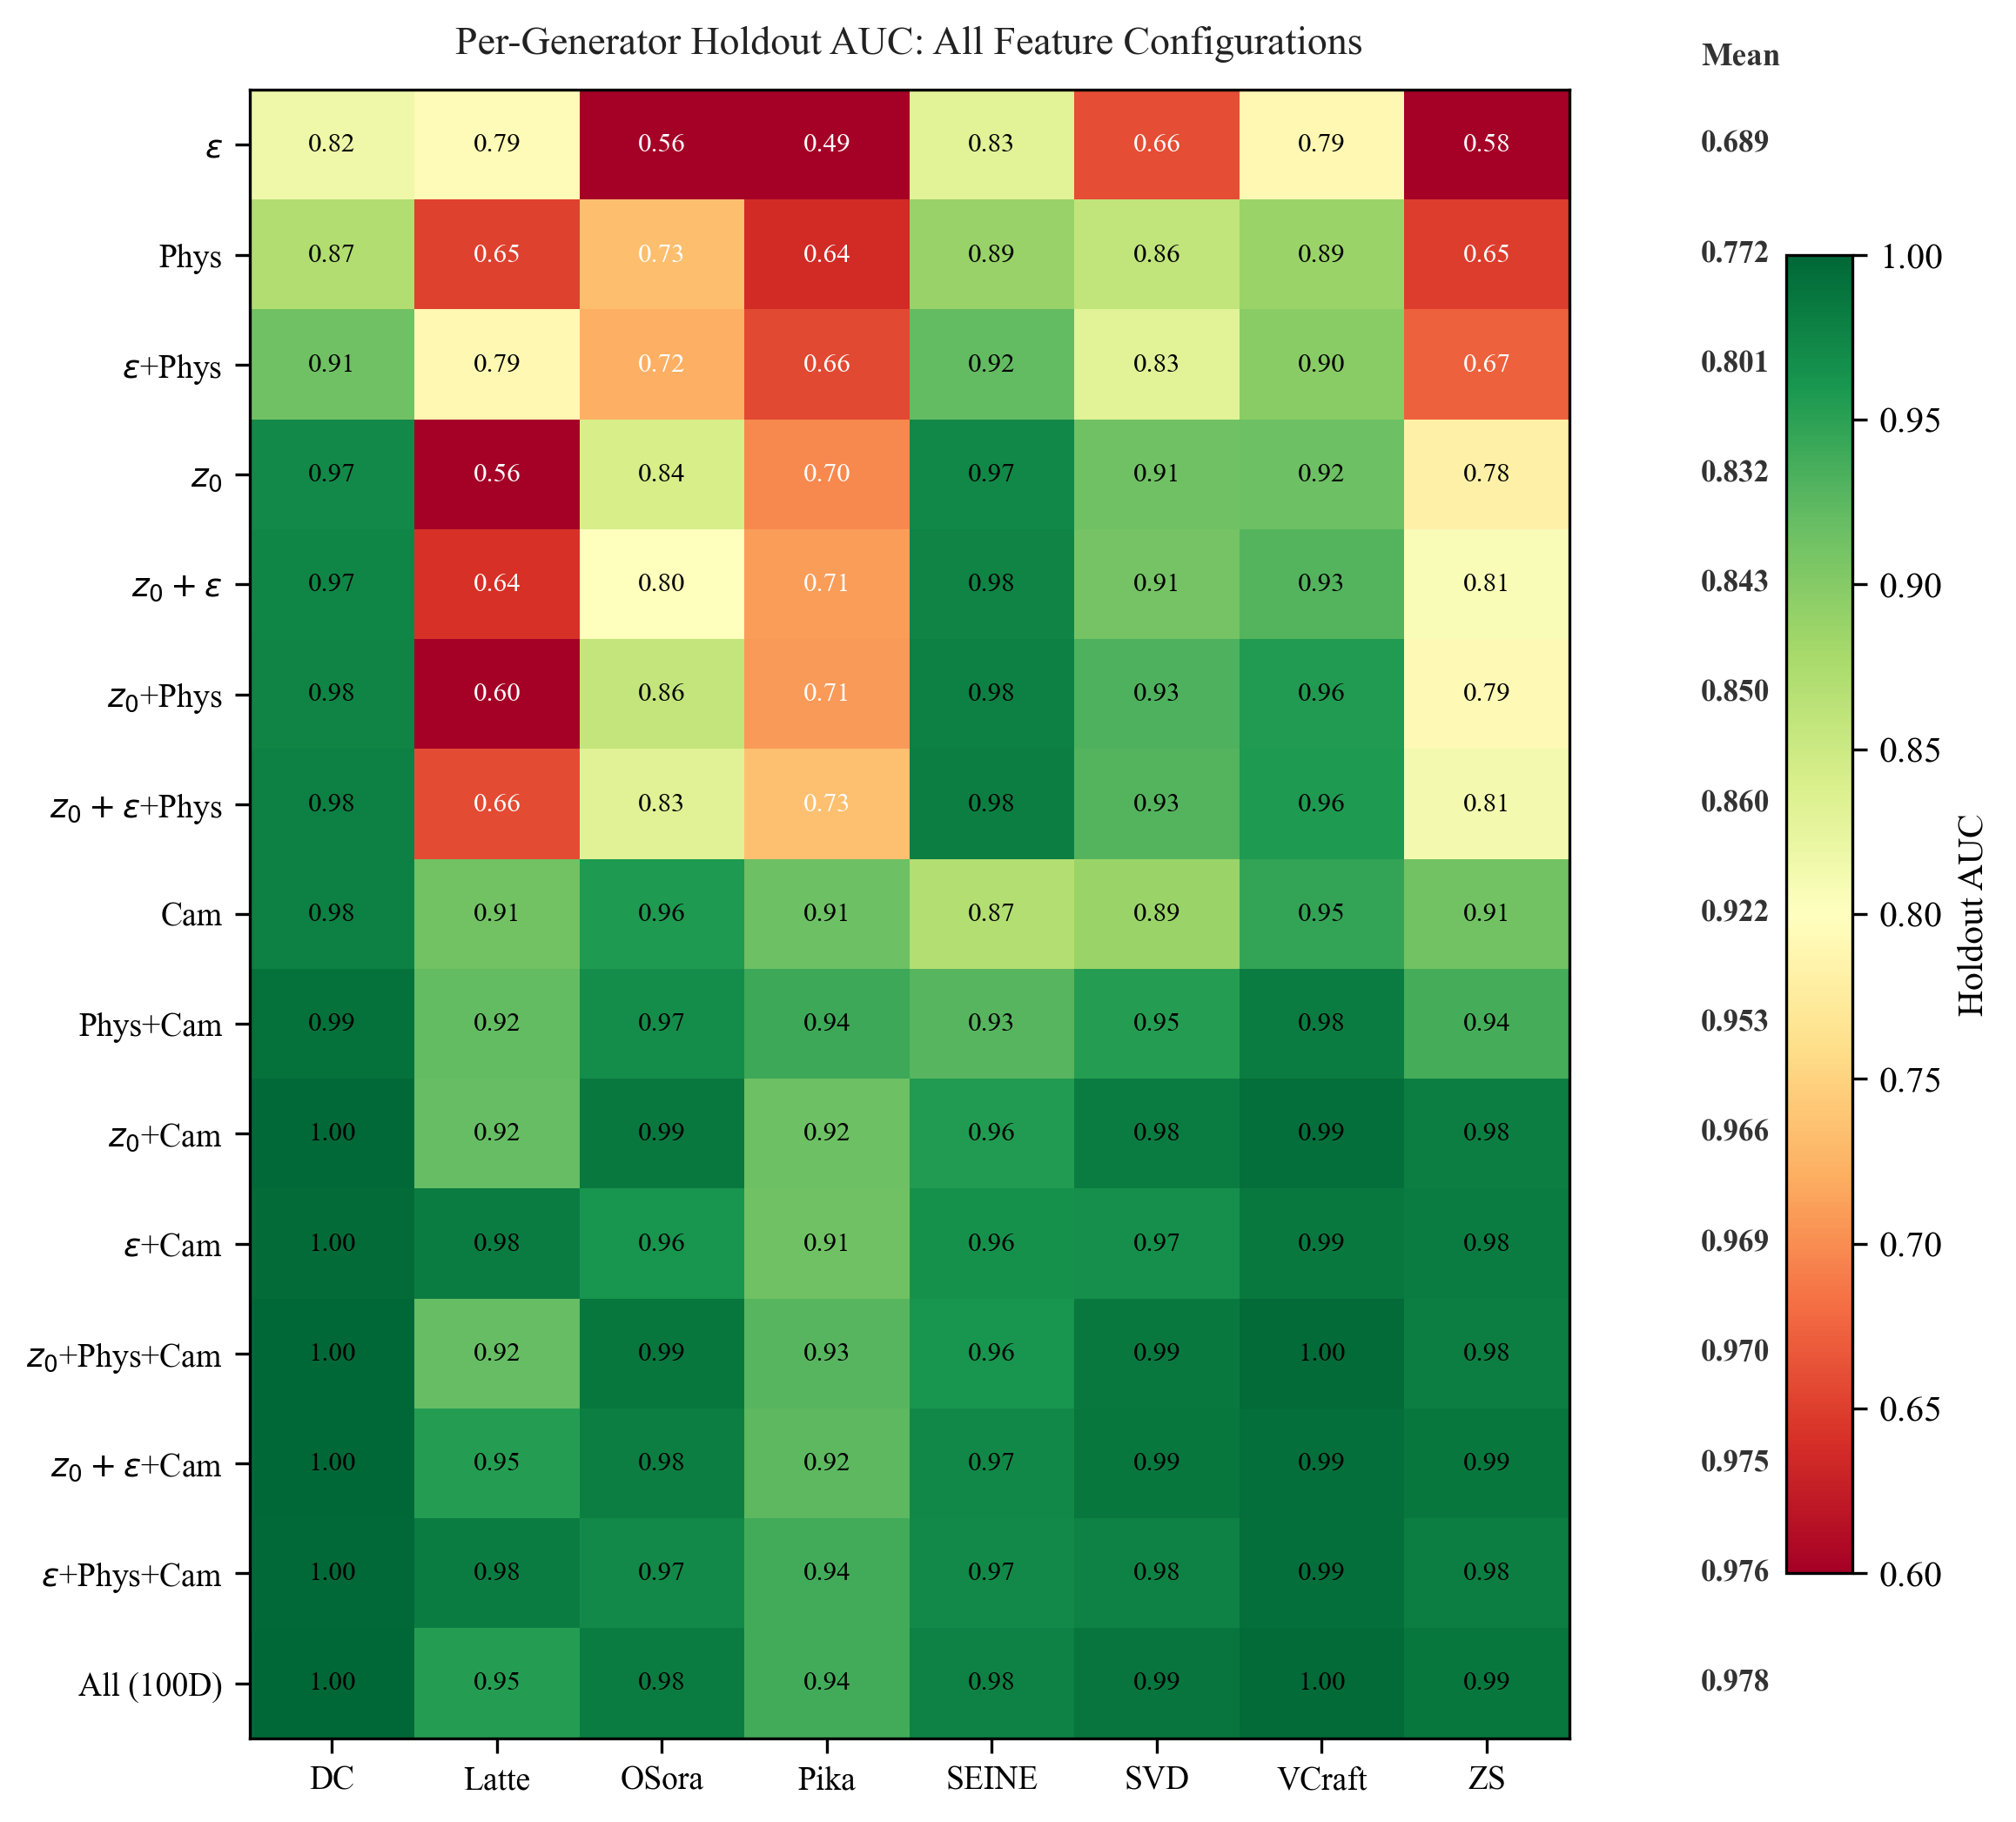

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size": 10,
    "figure.dpi": 300,
    "text.usetex": False,
    "axes.axisbelow": True,
})

df = pd.read_csv("../results/ablation/results_ablation.csv")

gen_cols = ["DynamicCrafter", "Latte", "OpenSora", "Pika", "SEINE", "SVD", "VideoCrafter", "ZeroScope"]
gen_short = ["DC", "Latte", "OSora", "Pika", "SEINE", "SVD", "VCraft", "ZS"]

label_map = {
    "latent": r"$z_0$",
    "noise": r"$\epsilon$",
    "physics": "Phys",
    "camera": "Cam",
    "latent+noise": r"$z_0+\epsilon$",
    "latent+physics": r"$z_0$+Phys",
    "latent+camera": r"$z_0$+Cam",
    "noise+physics": r"$\epsilon$+Phys",
    "noise+camera": r"$\epsilon$+Cam",
    "physics+camera": "Phys+Cam",
    "latent+noise+physics": r"$z_0+\epsilon$+Phys",
    "latent+noise+camera": r"$z_0+\epsilon$+Cam",
    "latent+physics+camera": r"$z_0$+Phys+Cam",
    "noise+physics+camera": r"$\epsilon$+Phys+Cam",
    "all": "All (100D)",
}

df_sorted = df.sort_values("mean", ascending=True).reset_index(drop=True)

display_labels = [label_map.get(r["config"], r["config"]) for _, r in df_sorted.iterrows()]
data = df_sorted[gen_cols].values

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(data, cmap="RdYlGn", vmin=0.6, vmax=1.0, aspect="auto")

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        color = "white" if v < 0.75 else "black"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5, color=color)

ax.set_xticks(range(len(gen_short)))
ax.set_xticklabels(gen_short, fontsize=9)
ax.set_yticks(range(len(display_labels)))
ax.set_yticklabels(display_labels, fontsize=9)

for i, (_, r) in enumerate(df_sorted.iterrows()):
    ax.text(len(gen_cols) + 0.3, i, f"{r['mean']:.3f}",
            ha="left", va="center", fontsize=8.5, fontweight="bold", color="#333333")

ax.text(len(gen_cols) + 0.3, -0.8, "Mean", ha="left", va="center",
        fontsize=9, fontweight="bold", color="#333333")

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.12)
cbar.set_label("Holdout AUC", fontsize=10)

ax.set_title("Per-Generator Holdout AUC: All Feature Configurations",
             pad=10, fontweight="normal", color="#222222")

plt.tight_layout(pad=0.8)

### Pairwise synergy Venn diagrams

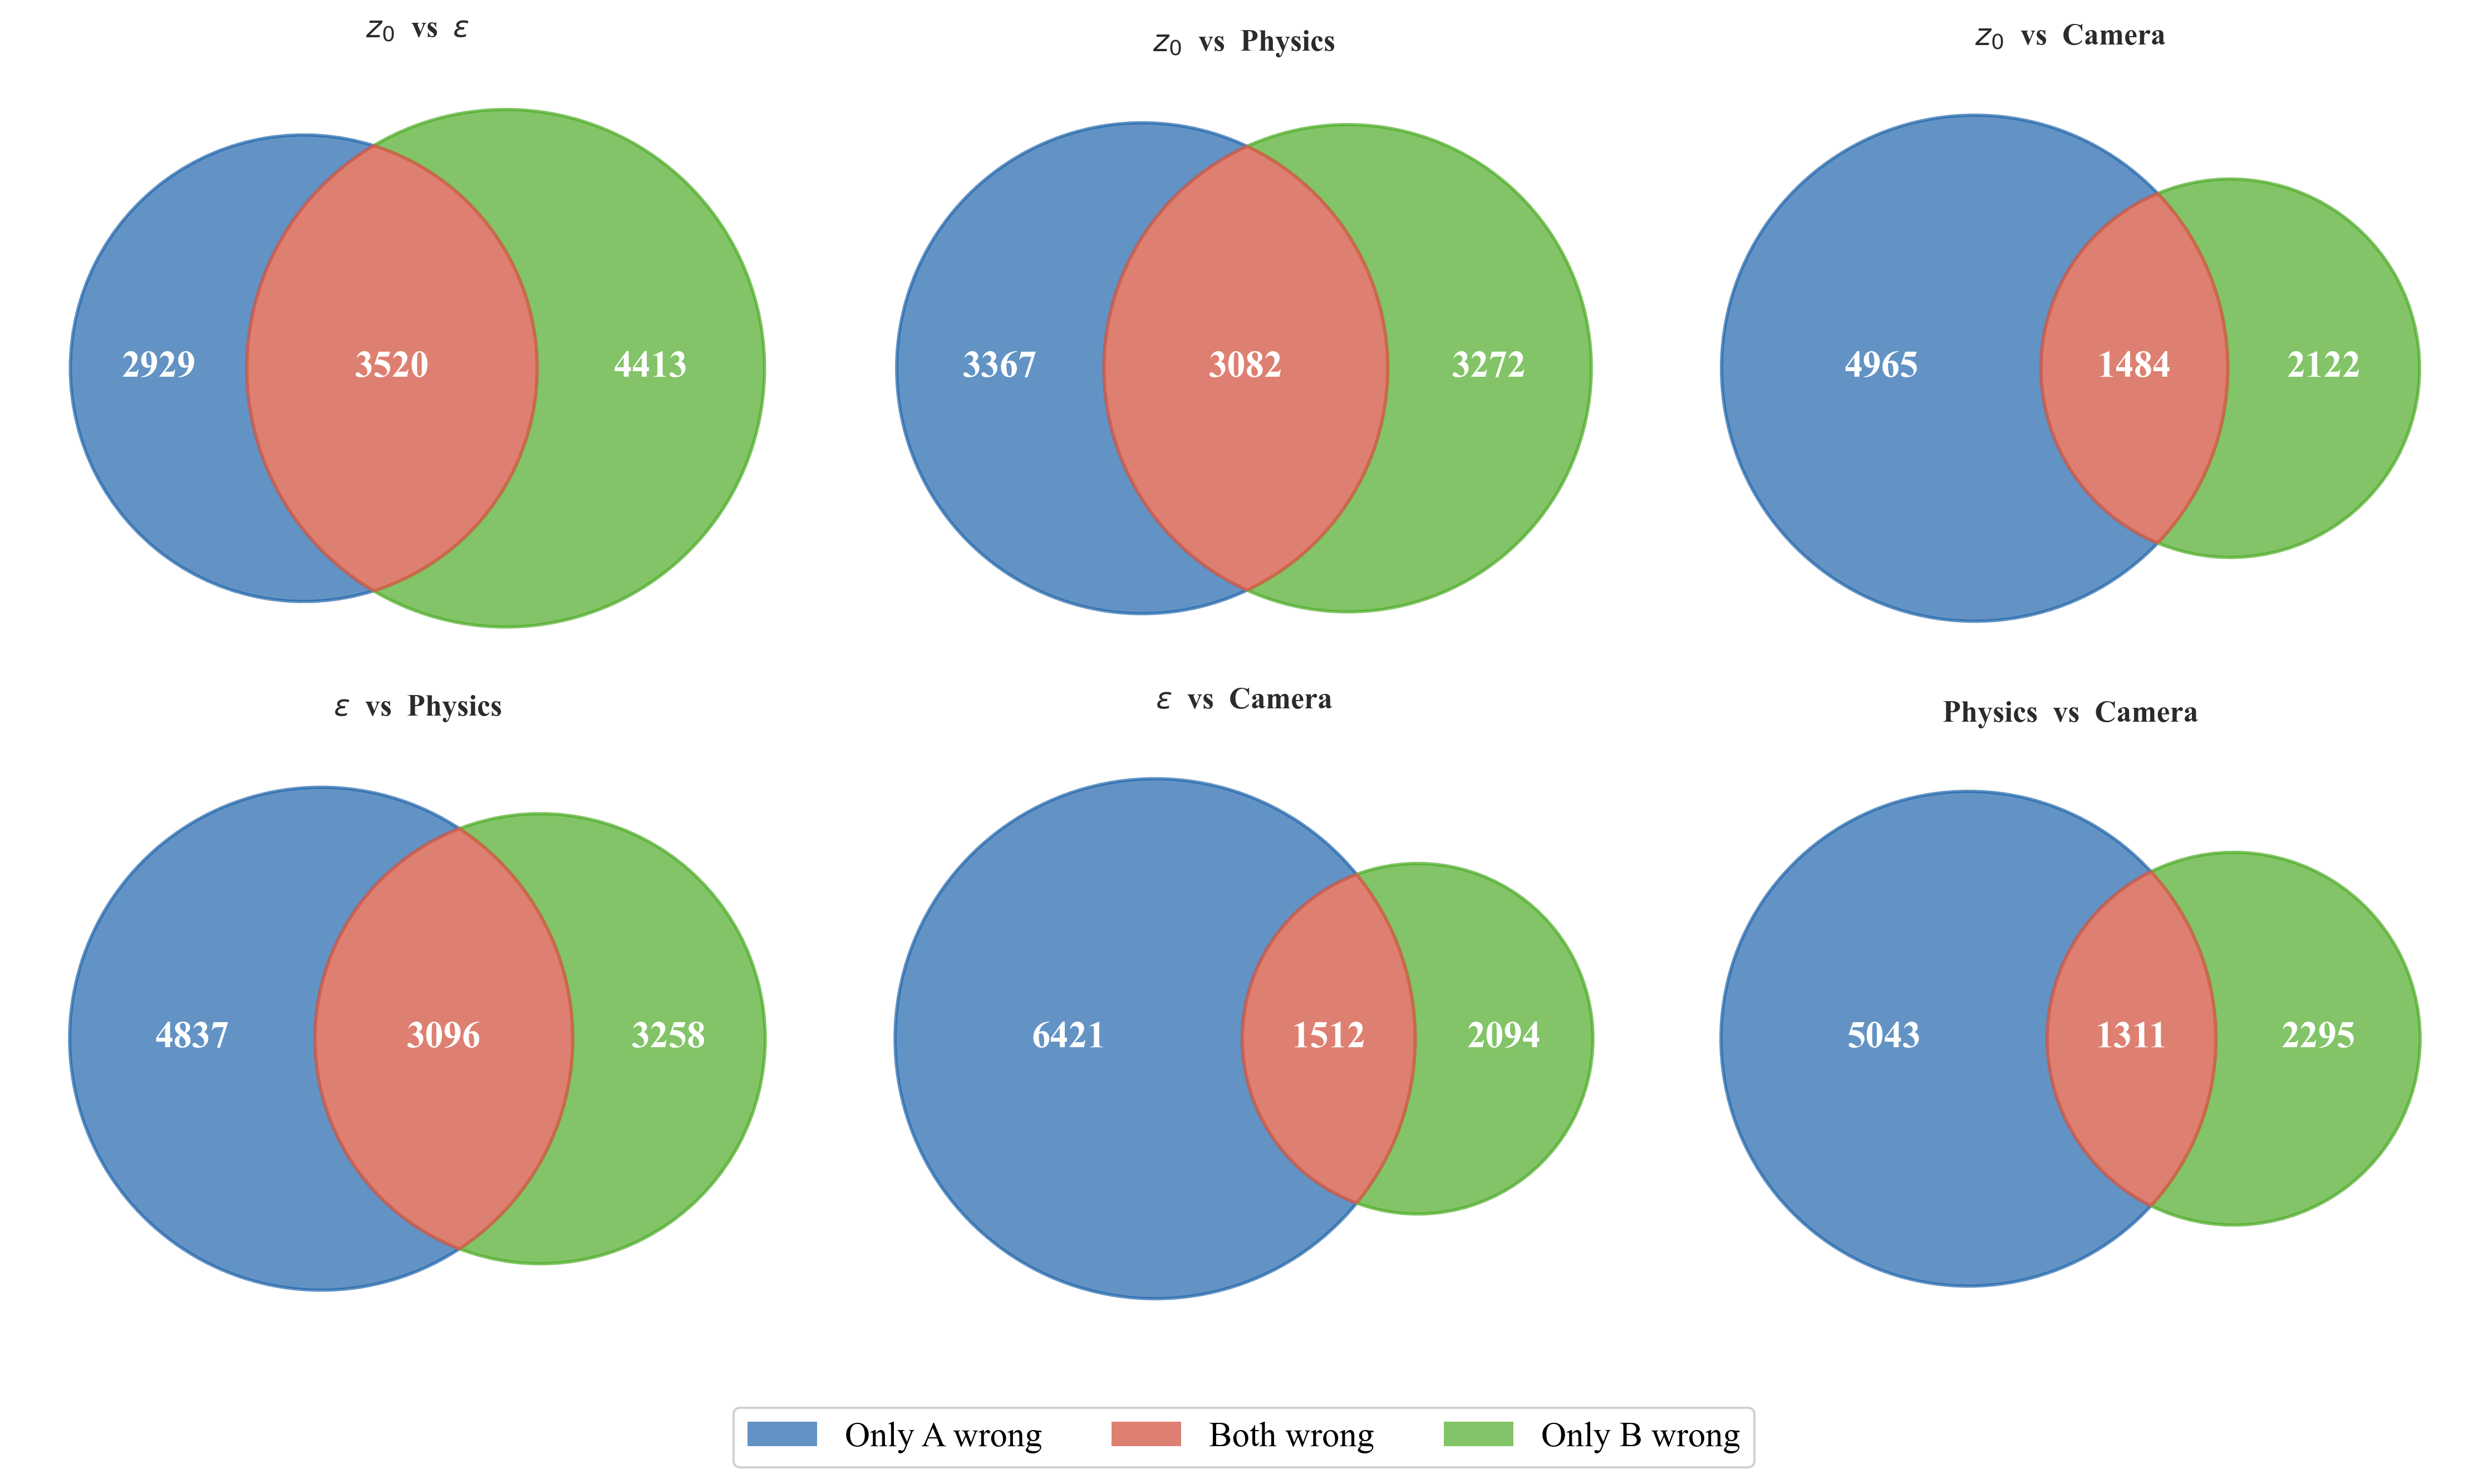

In [18]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from matplotlib.patches import Patch
from itertools import combinations

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size": 10, "figure.dpi": 300, "text.usetex": False,
})

C1 = "#2166ac"; C2 = "#d6604d"; C3 = "#4dac26"
TEXT = "#2b2b2b"; SUB = "#555555"

branch_labels = {
    "latent": r"$z_0$", "noise": r"$\epsilon$",
    "physics": "Physics", "camera": "Camera",
}

pairwise_venn_data = {
    ("latent", "noise"): (2929, 3520, 4413),
    ("latent", "physics"): (3367, 3082, 3272),
    ("latent", "camera"): (4965, 1484, 2122),
    ("noise", "physics"): (4837, 3096, 3258),
    ("noise", "camera"): (6421, 1512, 2094),
    ("physics", "camera"): (5043, 1311, 2295),
}

pairs = list(pairwise_venn_data.keys())
fig, axes = plt.subplots(2, 3, figsize=(15, 9), facecolor="white")

for idx, (a, b) in enumerate(pairs):
    ax = axes[idx // 3, idx % 3]
    left_only, overlap, right_only = pairwise_venn_data[(a, b)]

    v = venn2(subsets=(left_only, right_only, overlap), set_labels=("", ""), ax=ax)

    if v.get_patch_by_id("10"):
        v.get_patch_by_id("10").set(color=C1, alpha=0.7, edgecolor=C1, linewidth=1.4)
    if v.get_patch_by_id("01"):
        v.get_patch_by_id("01").set(color=C3, alpha=0.7, edgecolor=C3, linewidth=1.4)
    if v.get_patch_by_id("11"):
        v.get_patch_by_id("11").set(color=C2, alpha=0.8, edgecolor=C2, linewidth=1.4)

    for rid in ["10", "11", "01"]:
        lbl = v.get_label_by_id(rid)
        if lbl:
            lbl.set_fontsize(16); lbl.set_fontweight("semibold"); lbl.set_color("white")

    for lbl in v.set_labels:
        if lbl: 
            lbl.set_visible(False)

    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): 
        sp.set_visible(False)

    a_short = branch_labels[a]
    b_short = branch_labels[b]
    ax.set_title(f"{a_short}  vs  {b_short}", fontsize=13, fontweight="bold", color=TEXT, pad=8)

    total = left_only + overlap + right_only
    # ax.text(0.5, -0.06, f"Overlap: {overlap} ({100*overlap/total:.0f}%)", transform=ax.transAxes, ha="center", fontsize=10, color=SUB)

legend_handles = [
    Patch(facecolor=C1, alpha=0.7, label="Only A wrong"),
    Patch(facecolor=C2, alpha=0.8, label="Both wrong"),
    Patch(facecolor=C3, alpha=0.7, label="Only B wrong"),
]

fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=15, frameon=True, framealpha=0.9, edgecolor="#cccccc",
           bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0.0, 0.06, 1.0, 1.0])

### UpSet plot -- error intersections across 4 branches

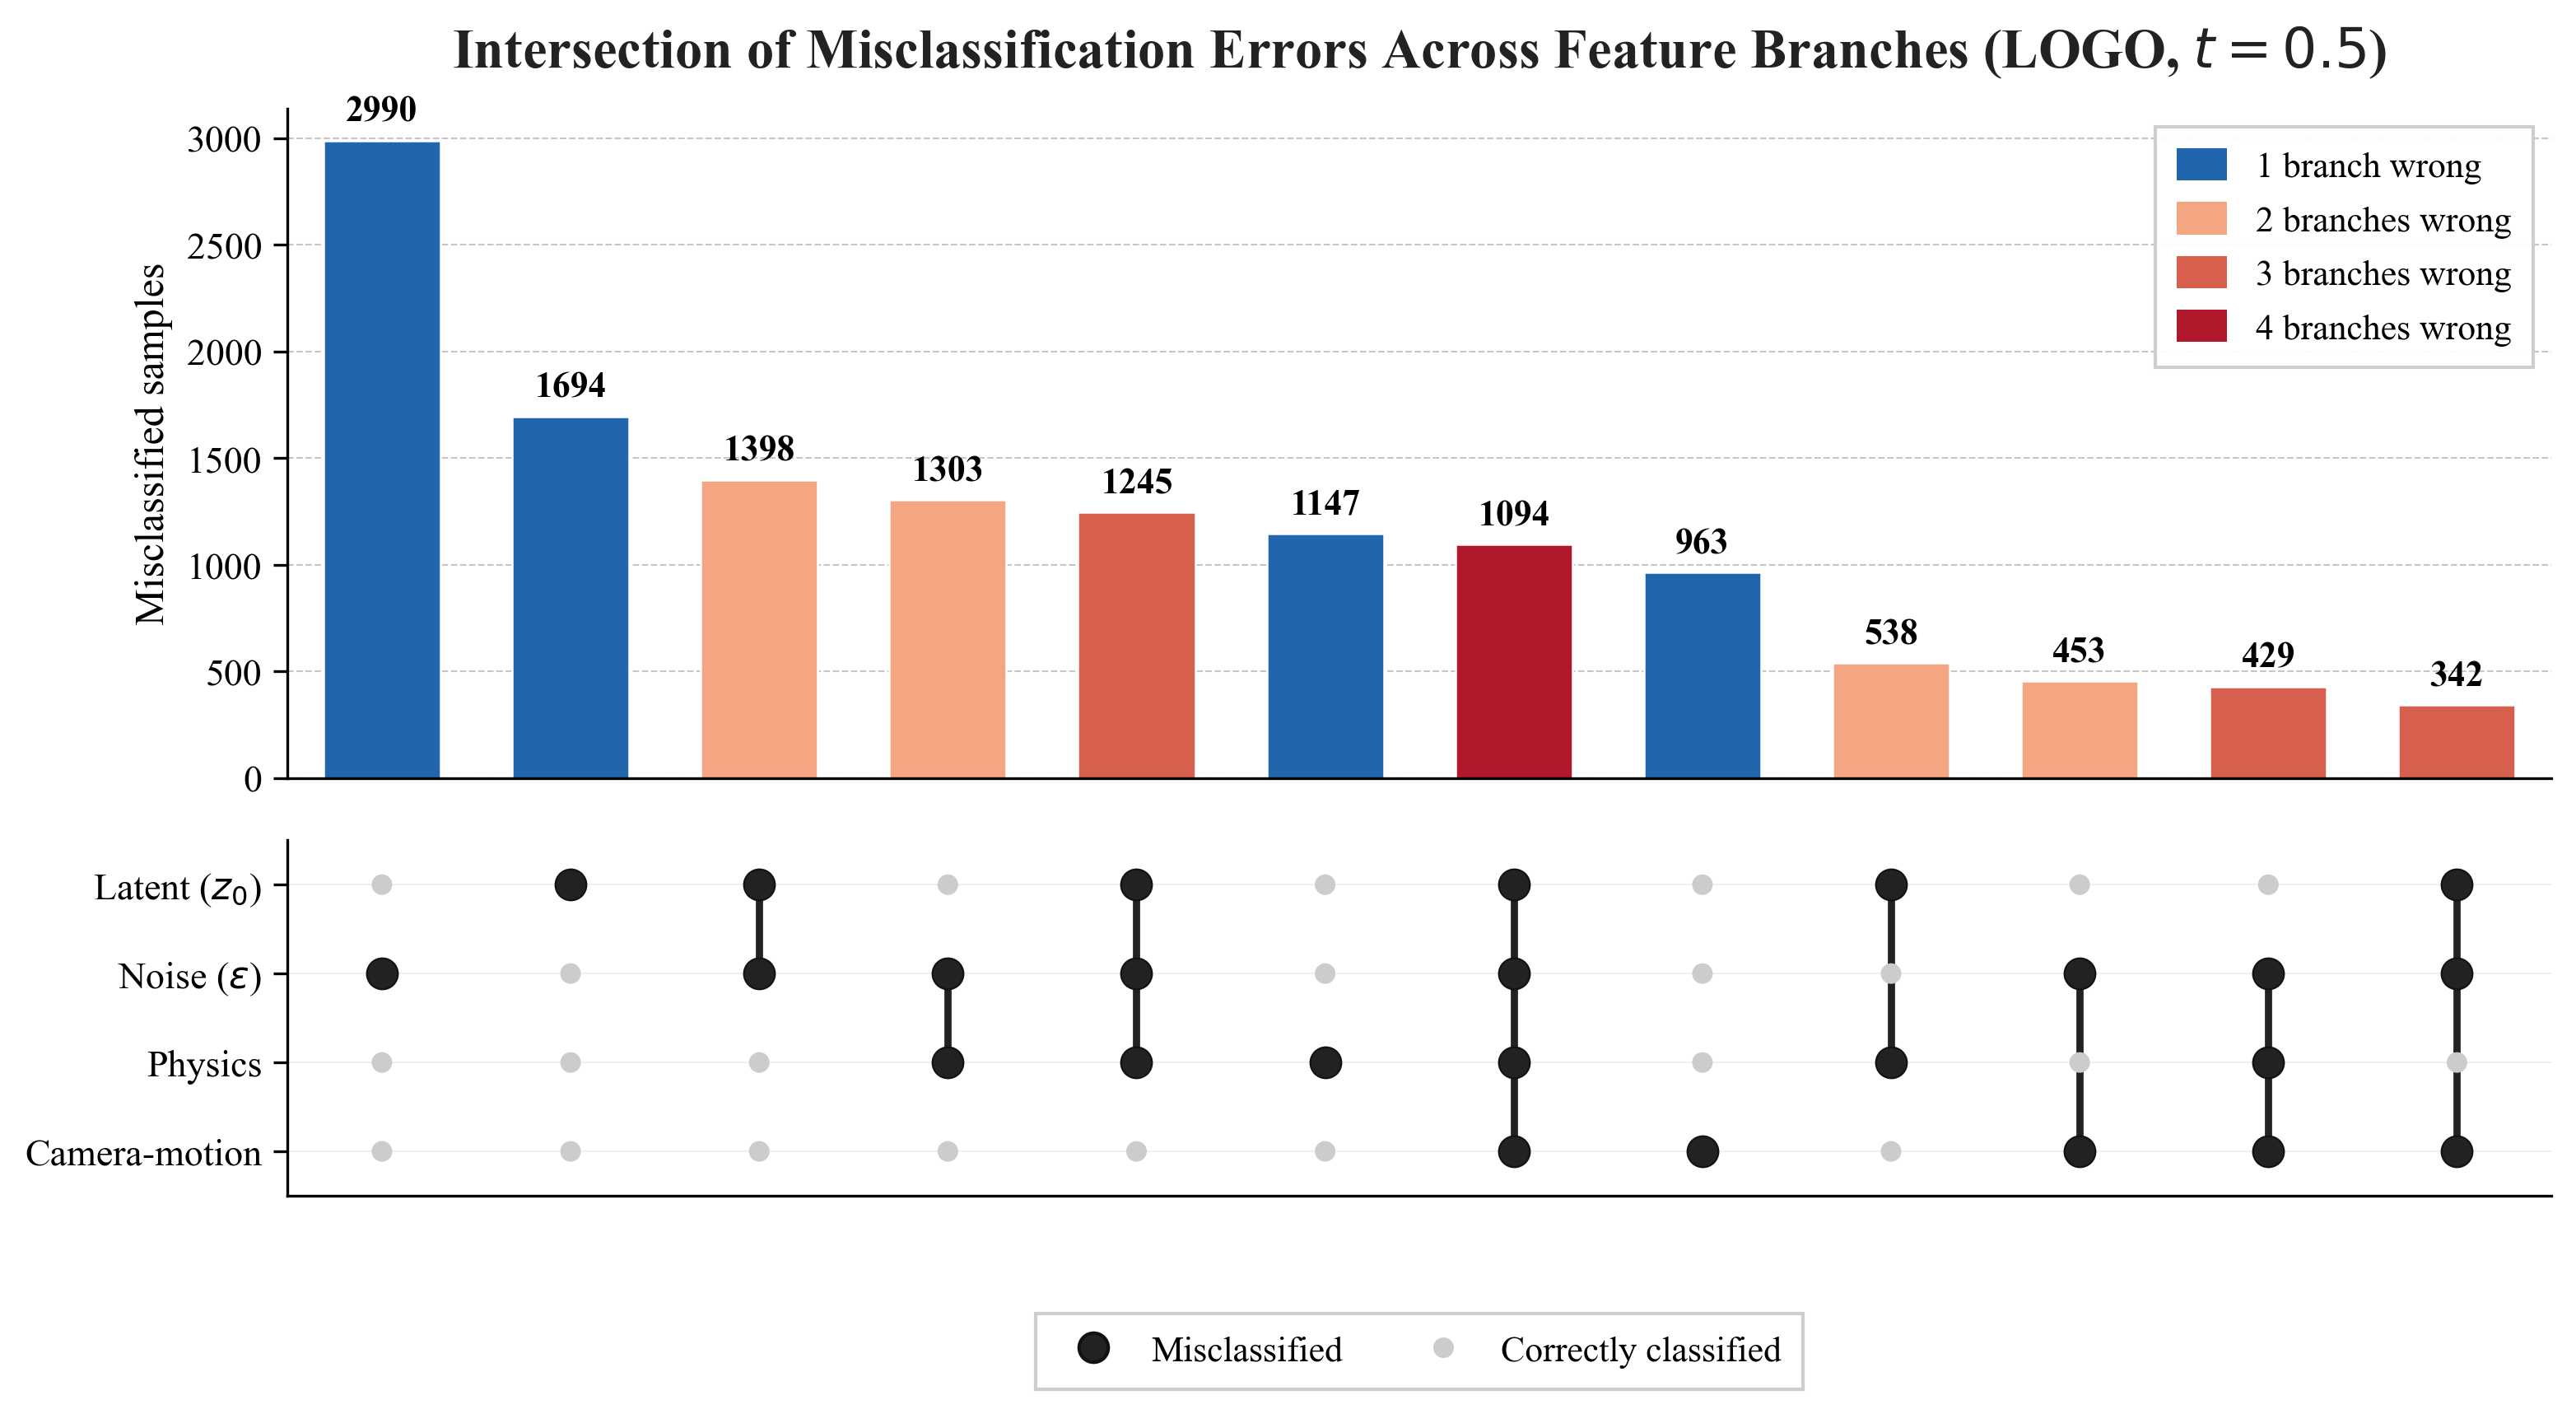

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size": 11,
    "figure.dpi": 300,
    "text.usetex": False,
    "axes.axisbelow": True,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10.5,
})

# branch order: latent, noise, physics, camera
patterns = [
    ((0, 1, 0, 0), 2990),
    ((1, 0, 0, 0), 1694),
    ((1, 1, 0, 0), 1398),
    ((0, 1, 1, 0), 1303),
    ((1, 1, 1, 0), 1245),
    ((0, 0, 1, 0), 1147),
    ((1, 1, 1, 1), 1094),
    ((0, 0, 0, 1), 963),
    ((1, 0, 1, 0), 538),
    ((0, 1, 0, 1), 453),
    ((0, 1, 1, 1), 429),
    ((1, 1, 0, 1), 342),
]

fig, (ax_bars, ax_dots) = plt.subplots(
    2, 1, figsize=(11, 6.4),
    gridspec_kw={"height_ratios": [3.2, 1.7]},
    sharex=True
)

x = np.arange(len(patterns))
counts = [c for _, c in patterns]

color_map = {1: "#2166ac", 2: "#f4a582", 3: "#d6604d", 4: "#b2182b"}
colors = [color_map[sum(p)] for p, _ in patterns]

ax_bars.bar(x, counts, color=colors, edgecolor="white", linewidth=0.6, width=0.62)

for i, c in enumerate(counts):
    ax_bars.text(i, c + max(counts) * 0.018, str(c),
                 ha="center", va="bottom", fontsize=10.5, fontweight="bold")

ax_bars.set_ylabel("Misclassified samples")
ax_bars.yaxis.grid(True, linestyle="--", alpha=0.3)
ax_bars.spines["top"].set_visible(False)
ax_bars.spines["right"].set_visible(False)
ax_bars.set_title(
    "Intersection of Misclassification Errors Across Feature Branches (LOGO, $t=0.5$)",
    pad=12, fontweight="bold", color="#222222", fontsize=16
)

bar_handles = [
    Patch(facecolor="#2166ac", label="1 branch wrong"),
    Patch(facecolor="#f4a582", label="2 branches wrong"),
    Patch(facecolor="#d6604d", label="3 branches wrong"),
    Patch(facecolor="#b2182b", label="4 branches wrong"),
]
ax_bars.legend(handles=bar_handles, loc="upper right", fontsize=10.5,
               framealpha=0.95, edgecolor="#cccccc", fancybox=False,
               borderpad=0.6, labelspacing=0.5, handlelength=1.4, handleheight=1.0)

branch_display = [r"Latent ($z_0$)", r"Noise ($\epsilon$)", "Physics", "Camera-motion"]

for i, (pattern, _) in enumerate(patterns):
    for j, val in enumerate(pattern):
        color = "#222222" if val == 1 else "#cccccc"
        size = 82 if val == 1 else 36
        ax_dots.scatter(i, j, c=color, s=size, zorder=3,
                        edgecolors="none" if val == 0 else "#111111", linewidths=0.5)
    active = [j for j, v in enumerate(pattern) if v == 1]
    if len(active) > 1:
        ax_dots.plot([i, i], [min(active), max(active)],
                     color="#222222", linewidth=2.1, zorder=2)

ax_dots.set_yticks(range(len(branch_display)))
ax_dots.set_yticklabels(branch_display, fontsize=11)
ax_dots.set_xlim(-0.5, len(patterns) - 0.5)
ax_dots.set_ylim(-0.5, len(branch_display) - 0.5)
ax_dots.invert_yaxis()
ax_dots.grid(True, alpha=0.08)
ax_dots.spines["top"].set_visible(False)
ax_dots.spines["right"].set_visible(False)
ax_dots.set_xticks([])

dot_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#222222",
           markeredgecolor="#111111", markersize=8.5, label="Misclassified"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#cccccc",
           markersize=7.0, label="Correctly classified"),
]
ax_dots.legend(handles=dot_handles, loc="upper center", bbox_to_anchor=(0.5, -0.28),
               ncol=2, fontsize=10.5, framealpha=0.95, edgecolor="#cccccc",
               fancybox=False, borderpad=0.6, columnspacing=1.8, handletextpad=0.6)

fig.tight_layout(rect=[0.02, 0.06, 0.98, 0.98])

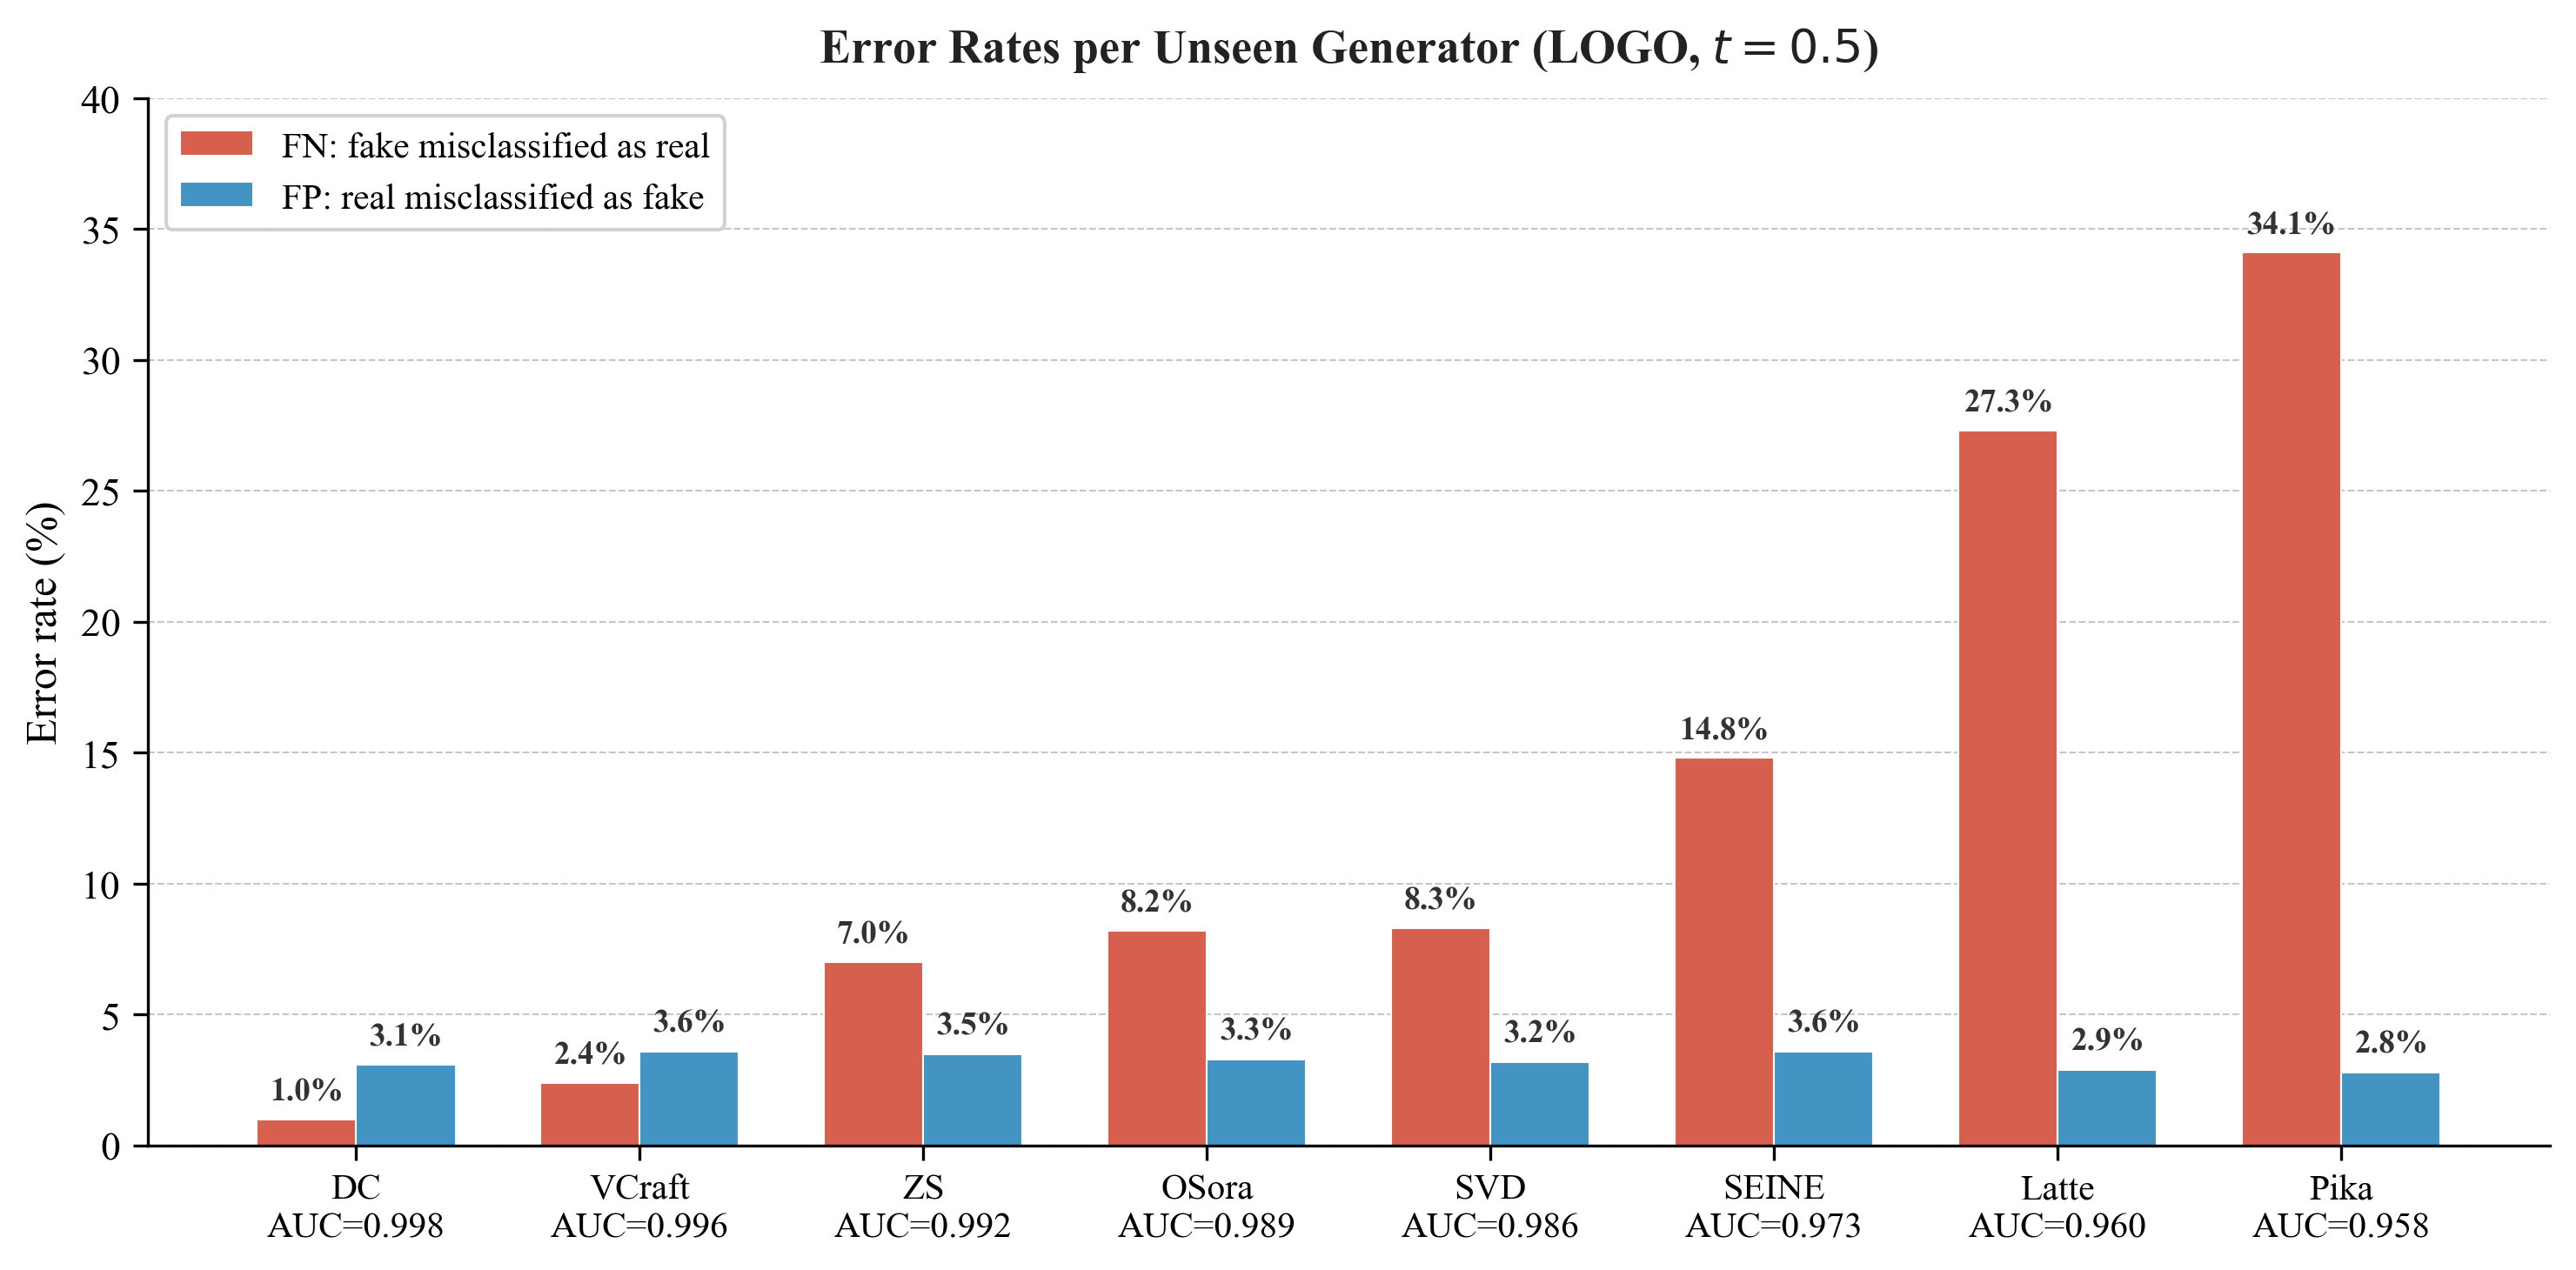

In [21]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size": 11,
    "figure.dpi": 300,
    "text.usetex": False,
    "axes.axisbelow": True,
})

generators = ["DC", "VCraft", "ZS", "OSora", "SVD", "SEINE", "Latte", "Pika"]
aucs = [0.998, 0.996, 0.992, 0.989, 0.986, 0.973, 0.960, 0.958]
fn_rates = [1.0,2.4,7.0,8.2,8.3,14.8,27.3,34.1]
fp_rates =[3.1,3.6,3.5,3.3,3.2,3.6,2.9,2.8]

x = np.arange(len(generators))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars_fn = ax.bar(x - width/2, fn_rates, width, label="FN: fake misclassified as real", color="#d6604d", edgecolor="white", linewidth=0.5)
bars_fp = ax.bar(x + width/2, fp_rates, width, label="FP: real misclassified as fake", color="#4393c3", edgecolor="white", linewidth=0.5)


for bar in bars_fn:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#333333")

for bar in bars_fp:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#333333")


xlabels = [f"{g}\nAUC={a:.3f}" for g, a in zip(generators, aucs)]
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=10)
ax.set_ylabel("Error rate (%)")
ax.set_ylim(0, 40)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
ax.set_title("Error Rates per Unseen Generator (LOGO, $t = 0.5$)", pad=10, fontweight="bold", color="#222222")

plt.tight_layout()